Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

Load Dataset

In [3]:
df = pd.read_csv("Heart_disease_cleveland_new.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


Features and Target

In [4]:
X = df.drop('target', axis=1)
y = df['target']

Apply SMOTE (Balancing Data)

In [5]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("Before balancing:\n", y.value_counts())
print("\nAfter balancing:\n", y_res.value_counts())

Before balancing:
 target
0    164
1    139
Name: count, dtype: int64

After balancing:
 target
0    164
1    164
Name: count, dtype: int64


. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

Train Models and Evaluate

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.71      0.83      0.77        30
           1       0.84      0.72      0.78        36

    accuracy                           0.77        66
   macro avg       0.78      0.78      0.77        66
weighted avg       0.78      0.77      0.77        66


Decision Tree
Accuracy: 0.7121212121212122
              precision    recall  f1-score   support

           0       0.68      0.70      0.69        30
           1       0.74      0.72      0.73        36

    accuracy                           0.71        66
   macro avg       0.71      0.71      0.71        66
weighted avg       0.71      0.71      0.71        66


Random Forest
Accuracy: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.71      0.83      0.77        30
           1       0.84      0.72      0.78        36

    accuracy                           0.77 

Accuracy Comparison Graph

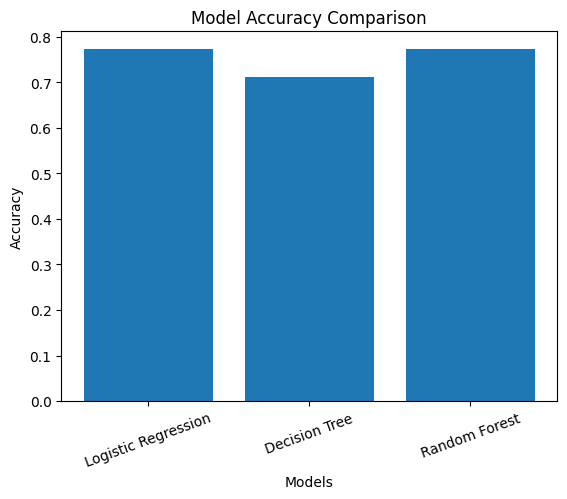

In [8]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

Confusion Matrix

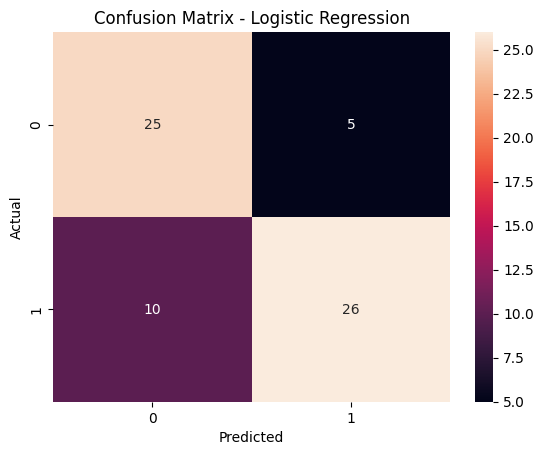

In [9]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

-Conclusion

- Data balancing using SMOTE improved model performance.
- Among the tested models, Random Forest achieved the highest accuracy.
- Evaluation metrics such as precision, recall, and F1-score improved after balancing.
- Visualization techniques helped in better understanding model performance.